<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/algorytmy_genetyczne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Zadania do samodzielnego wykonania

1.

Proszę zaproponować swoją implementację algorytmu genetycznego w celu znalezienia maksimum funkcji  
$$
f(x) = \cos(80x + 0.3) + 3x^{-0.9} - 2
$$  
w przedziale $[0.01, 1]$. Dla $x = 0$ proszę przyjąć $f(x) = 0$ (choć nie powinno być używane w zadaniu). Proszę porównać działanie algorytmu:

* Dla kodowania w naturalnym kodzie binarnym i w kodzie Graya
* Dla szansy mutacji wynoszącej 0, 0.1, 0.5 i 1.0
* Dla selekcji ruletkowej i dla selekcji progowej. W selekcji progowej dzielimy populację na dwie grupy: na $\gamma\%$ najlepszych i na pozostałych. Osobniki w grupie $\gamma\%$ najlepszych mają równą szansę na reprodukcję, pozostałe mają zerową szansę na reprodukcję. Proszę sprawdzić wyniki dla $\gamma = 30$ i $\gamma = 60$.

Za każdym razem proszę podać średnie wyniki dla 10 wywołań algorytmu i przedstawić przykładowe przebiegi algorytmu na wykresach (dla jednego z wywołań).

2.

W mieście, reprezentowanym za pomocą kwadratowej siatki, operujemy siecią pizzerii. Ich lokalizacje znajdują się w kwadratach o pozycjach (1,1), (2,6), (5,4), (7,1), albo jak pokazano na obrazku poniżej.

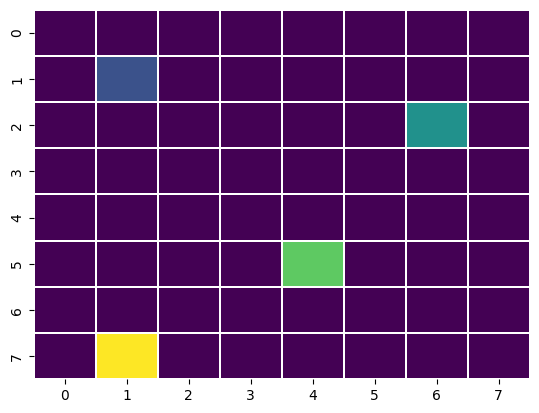

Zyski sieci zależą od budżetu wyłożonego na cztery pizzerie ($B_1$, $B_2$, $B_3$, $B_4$), gdzie każdy budżet jest w zakresie od **0 do 400** (nie może wyjść poza te wartości). Zysk jest liczony w następujący sposób:

$$
Z = \sum_{i=0}^8 \sum_{j=0}^8 \frac{z_{i,j}^1 + z_{i,j}^2 + z_{i,j}^3 + z_{i,j}^4}{4} - (B_1+B_2+B_3+B_4)^{1.15}
$$

Gdzie $z_{i,j}^k$ jest dochodem $k$-tej pizzerii na polu $(i,j)$. Innymi słowy, sumujemy **średnie zyski** z danego pola dla wszystkich pizzerii i odejmujemy od tego skorygowaną (potęgowaną) sumę budżetów — ze względu na konieczność rozbudowy lokali, większe trudności w utrzymaniu itp.

Zysk $k$-tej pizzerii na polu $(i,j)$ liczymy natomiast następująco:

Najpierw liczymy $d$, czyli odległość taksówkarską (taxicab, Manhattan Distance) między pizzerią a tym polem.

- Jeżeli $d$ jest **mniejsza** niż 2:

$$
z = 1.3 \cdot \frac{B}{0.5d + 4}
$$

- Jeżeli $d$ jest **większa lub równa** 2:

$$
z = \frac{B}{0.5d + 4}
$$

---

Proszę zaprojektować **algorytm genetyczny**, który otrzyma jak najwyższą wartość funkcji $Z(B_1, B_2, B_3, B_4)$ i przedstawić, jak radzi sobie przy 10 wywołaniach (jak wygląda średnia wyniku i odchylenie standardowe).

Proszę samodzielnie wybrać **kodowanie** (rzeczywistoliczbowe, całkowitoliczbowe, binarne), wybrać **algorytm mutacji i selekcji**, oraz przeprowadzić **testy parametrów**.


Kolokwium
metryka taka taka jaki jest wniosek
najlepsze rozwiąnie != nie najbardziej optymalne


In [ ]:
class Solution:
  def __init__(self, encoding = 'binary'):
    self.encoding = encoding
    self.genes = [random.randint(0,1) for _ in range(16)]


  def decode(self):
    if self.encoding == 'gray':
      binary_genes = [self.genes[0]]
      for i in range(1, len(self.genes)):
        binary_genes.append(binary_genes[i - 1] ^ self.genes[i])
    else:
      binary_genes = self.genes

    val = int("".join(str(x) for x in binary_genes), 2)
    return 0.01 + (val / (2**16 - 1)) * (1 - 0.01)

  # funkcja przystosowania:
  def get_adaptation(self):
    number = self.decode()
    return math.cos(80 * number + 0.3) + 3 * (number**-0.9) - 2

  # krzyżowanie jednopunktowe z innym osobnikiem:
  def crossover(self, other_solution):
    cut_position = random.randint(0,15)
    new_solution = Solution(encoding=self.encoding)
    new_solution.genes[0:cut_position] = self.genes[0:cut_position]
    new_solution.genes[cut_position:] = other_solution.genes[cut_position:]
    return new_solution

  # mutacja przez obrót bitu na losowej pozycji:
  def mutation(self):
    mutation_position = random.randint(0,15)
    if self.genes[mutation_position] == 1:
      self.genes[mutation_position] = 0
    else:
      self.genes[mutation_position] = 1

Konfiguracja 0 (binary, mut:0.1, sel:roulette): Średnia z 10 prób = 187.5112
Konfiguracja 1 (gray, mut:0.1, sel:roulette): Średnia z 10 prób = 185.8102
Konfiguracja 2 (binary, mut:0.0, sel:roulette): Średnia z 10 prób = 157.1496
Konfiguracja 3 (binary, mut:0.1, sel:roulette): Średnia z 10 prób = 187.5867
Konfiguracja 4 (binary, mut:0.5, sel:roulette): Średnia z 10 prób = 187.7408
Konfiguracja 5 (binary, mut:1.0, sel:roulette): Średnia z 10 prób = 187.7408
Konfiguracja 6 (binary, mut:0.1, sel:threshold): Średnia z 10 prób = 187.7408
Konfiguracja 7 (binary, mut:0.1, sel:threshold): Średnia z 10 prób = 187.7408


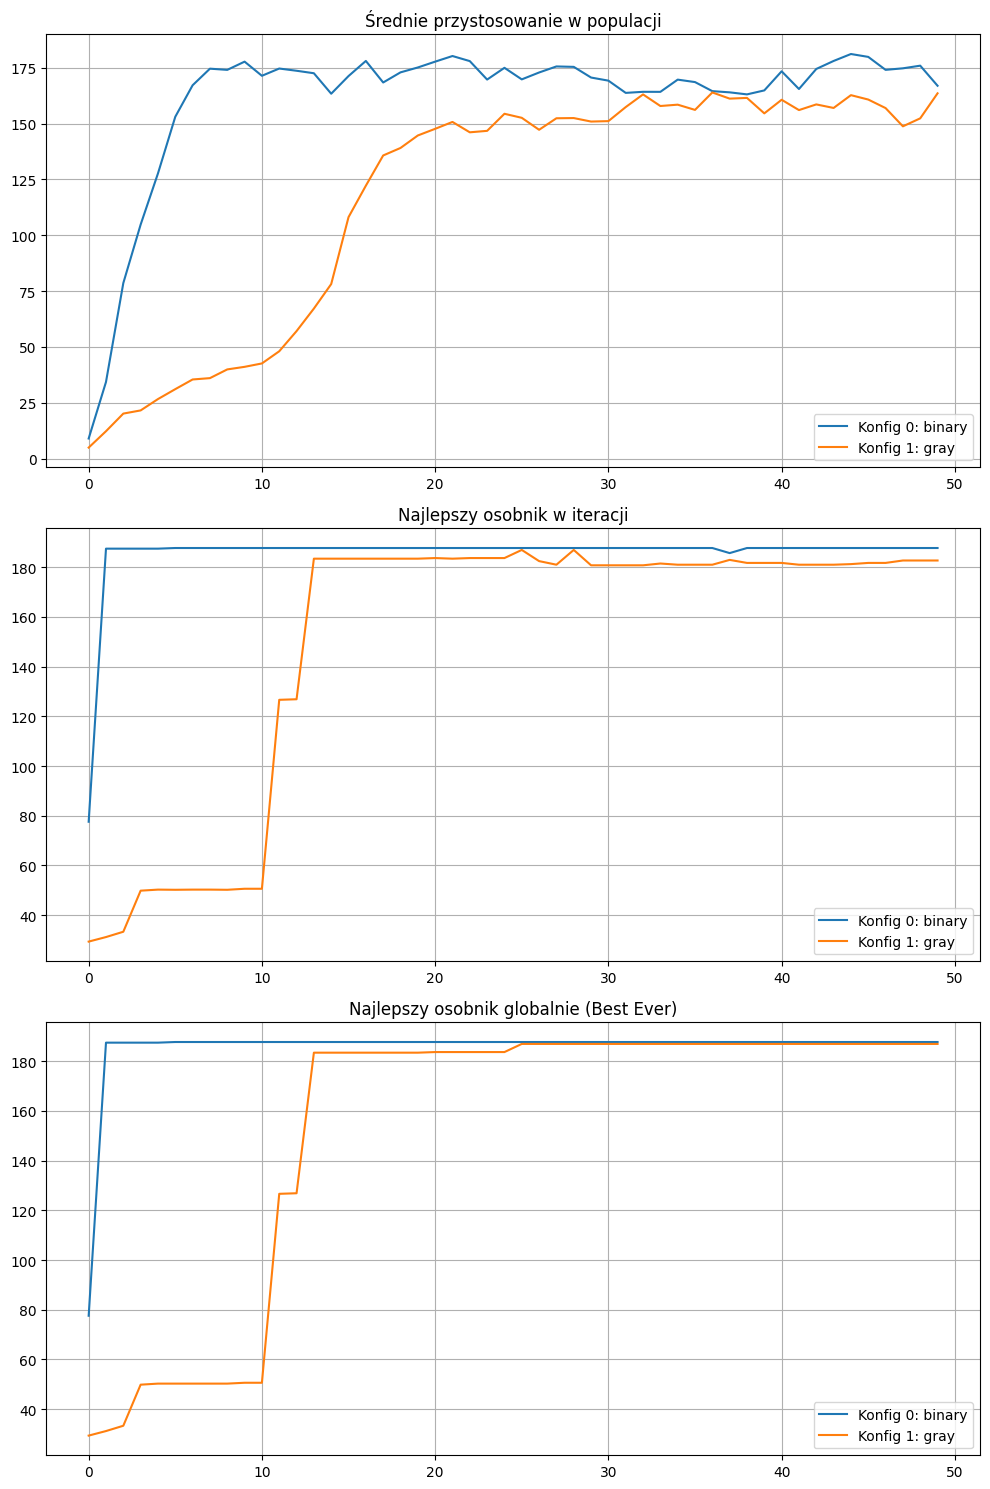

In [ ]:
import matplotlib.pyplot as plt
import random
import math

# Parametry
population_size = 50
iterations = 50
runs_per_conf = 10
configs = [
    {'encoding': 'binary', 'mutation': 0.1, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'gray', 'mutation': 0.1, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'binary', 'mutation': 0.0, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'binary', 'mutation': 0.1, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'binary', 'mutation': 0.5, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'binary', 'mutation': 1.0, 'selection': 'roulette', 'gamma': 0},
    {'encoding': 'binary', 'mutation': 0.1, 'selection': 'threshold', 'gamma': 30},
    {'encoding': 'binary', 'mutation': 0.1, 'selection': 'threshold', 'gamma': 60}
]

all_results = {}

for idx, conf in enumerate(configs):
    run_final_bests = []

    # Dane dla wykresów z ostatniego wywołania
    final_avgs = []
    final_bests_local = []
    final_bests_global = []

    for run in range(runs_per_conf):
        population = [Solution(encoding = conf['encoding']) for _ in range(population_size)]
        best_solution_adaptation = -float('inf')

        avgs = []
        bests_local = []
        bests_global = []

        for iteration in range(iterations):
            #  Obliczenie przystosotwania
            adaptations = [p.get_adaptation() for p in population]

            # Aktualizacja najlepszego osobnika
            local_best_val = max(adaptations)
            if local_best_val > best_solution_adaptation:
                best_solution_adaptation = local_best_val

            # Logowanie statystyk
            avgs.append(sum(adaptations) / len(adaptations))
            bests_local.append(local_best_val)
            bests_global.append(best_solution_adaptation)

            if conf['selection'] == 'roulette':
                # Koło ruletki
                mini, maxi = min(adaptations), max(adaptations)
                weights = [(a - mini) / (maxi - mini) if maxi != mini else 1.0 for a in adaptations]
                parents = [random.choices(population, weights=weights, k=2) for _ in range(population_size)]

            elif conf['selection'] == 'threshold':
                scored = sorted(zip(population, adaptations), key=lambda x: x[1], reverse=True)
                num_best = max(1, int(population_size * (conf['gamma'] / 100.)))
                eligible = [x[0] for x in scored[:num_best]]
                parents = [random.choices(eligible, k=2) for _ in range(population_size)]

            # dzieci i mutujacje
            children = [p[0].crossover(p[1]) for p in parents]
            for c in children:
                if random.random() < conf['mutation']:
                    c.mutation()
            population = children

        run_final_bests.append(best_solution_adaptation)

        # Zapisujs danych do wykresu ale tylko z ostatnioego dla przejrzystości
        if run == runs_per_conf - 1:
            final_avgs, final_bests_local, final_bests_global = avgs, bests_local, bests_global


    avg_total = sum(run_final_bests) / runs_per_conf
    print(f"Konfiguracja {idx} ({conf['encoding']}, mut:{conf['mutation']}, sel:{conf['selection']}): Średnia z 10 prób = {avg_total:.4f}")

    all_results[idx] = {
        'conf': conf,
        'avgs': final_avgs,
        'bests_local': final_bests_local,
        'bests_global': final_bests_global
    }

# --- WYKRESY (Przykładowe przebiegi dla wybranych konfiguracji) ---
indices_to_plot = [0, 1]

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for i in indices_to_plot:
    label = f"Konfig {i}: {all_results[i]['conf']['encoding']}"
    axs[0].plot(all_results[i]['avgs'], label=label)
    axs[1].plot(all_results[i]['bests_local'], label=label)
    axs[2].plot(all_results[i]['bests_global'], label=label)

axs[0].set_title("Średnie przystosowanie w populacji")
axs[1].set_title("Najlepszy osobnik w iteracji")
axs[2].set_title("Najlepszy osobnik globalnie (Best Ever)")

for ax in axs:
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import random

# Lokalizacje pizzerii (x, y)
LOCATIONS = [(1, 1), (2, 6), (5, 4), (7, 1)]

def calculate_z_ij_k(B, p_pos, grid_pos):
    # Manhattan distance
    d = abs(p_pos[0] - grid_pos[0]) + abs(p_pos[1] - grid_pos[1])

    if d < 2:
        return 1.3 * (B / (0.5 * d + 4))
    else:
        return B / (0.5 * d + 4)

def fitness_function(budgets):
    # budgets to lista [B1, B2, B3, B4]
    total_grid_profit = 0

    # Sumujemy zyski po polach siatki 0-7 (8x8)
    for i in range(8):
        for j in range(8):
            sum_z = 0
            for k in range(4):
                sum_z += calculate_z_ij_k(budgets[k], LOCATIONS[k], (i, j))
            total_grid_profit += (sum_z / 4.0)

    total_cost = sum(budgets) ** 1.15
    return total_grid_profit - total_cost

class GeneticAlgorithm:
    def __init__(self, pop_size=50, mut_rate=0.2, generations=100, selection_type='tournament'):
        self.pop_size = pop_size
        self.mut_rate = mut_rate
        self.generations = generations
        self.selection_type = selection_type
        self.population = [np.random.uniform(0, 400, 4) for _ in range(pop_size)]

    def mutate(self, individual):
        if random.random() < self.mut_rate:
            # Mutacja gaussowska o odchyleniu 20 (5% zakresu)
            mutation = np.random.normal(0, 20, 4)
            individual = np.clip(individual + mutation, 0, 400)
        return individual

    def crossover(self, p1, p2):
        # Krzyżowanie arytmetyczne
        alpha = random.random()
        child = alpha * p1 + (1 - alpha) * p2
        return child

    def selection(self, fits):
          if self.selection_type == 'tournament':
              # Selekcja turniejowa (rozmiar 3)
              idx = random.sample(range(self.pop_size), 3)
              best_idx = idx[np.argmax([fits[i] for i in idx])]
              return self.population[best_idx]
          else:
              # Selekcja ruletkowa
              min_fit = min(fits)
              # Przesunięcie, aby najsłabszy nie miał szansy 0, jeśli zyski są ujemne
              adjusted_fits = [f - min_fit + 1 for f in fits]
              total_fit = sum(adjusted_fits)
              probs = [f / total_fit for f in adjusted_fits]
              return self.population[np.random.choice(range(self.pop_size), p=probs)]

    def run(self):
        for _ in range(self.generations):
            fits = [fitness_function(ind) for ind in self.population]
            new_population = []

            # Elityzm
            new_population.append(self.population[np.argmax(fits)])

            while len(new_population) < self.pop_size:
                p1 = self.selection(fits)
                p2 = self.selection(fits)
                child = self.crossover(p1, p2)
                child = self.mutate(child)
                new_population.append(child)

            self.population = new_population

        final_fits = [fitness_function(ind) for ind in self.population]
        return max(final_fits)

# --- TESTY: 10 WYWOŁAŃ ---
configs = [
    {'selection': 'tournament', 'mut': 0.1, 'desc': 'Turniej + Mała mutacja'},
    {'selection': 'tournament', 'mut': 0.4, 'desc': 'Turniej + Duża mutacja'},
    {'selection': 'roulette',   'mut': 0.1, 'desc': 'Ruletka + Mała mutacja'}
]

print(f"{'Konfiguracja':<30} | {'Średnia (10 prób)':<20} | {'Odchylenie':<12}")
print("-" * 70)

for conf in configs:
    run_results = []
    for _ in range(10):
        ga = GeneticAlgorithm(
            pop_size=60,
            mut_rate=conf['mut'],
            generations=100,
            selection_type=conf['selection']
        )
        run_results.append(ga.run())

    mean_z = np.mean(run_results)
    std_z = np.std(run_results)

    print(f"{conf['desc']:<30} | {mean_z:<20.2f} | {std_z:<12.2f}")

Konfiguracja                   | Średnia (10 prób)    | Odchylenie  
----------------------------------------------------------------------
Turniej + Mała mutacja         | 126.36               | 0.00        
Turniej + Duża mutacja         | 126.36               | 0.00        
Ruletka + Mała mutacja         | 123.74               | 3.78        
